In [1]:
!pip install ultralytics
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 4.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 112.1 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sou

In [2]:
!nvidia-smi

Fri Apr 24 06:40:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# import the model we used is the medium version of the YOLOv8 model, you can use the small version or the large version as well
from ultralytics import YOLO
model=YOLO('yolov8m.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# import the dataset and give the path to the data.yaml file in the data parameter
# dataset Link: https://universe.roboflow.com/wildlife-detection-frujm/wildlife-detection-5gnjr/dataset/2
result  = model.train(
    data = '/kaggle/input/datasets/shivamvachhnai/wildlife/data.yaml',
    epochs= 100,
    imgsz=640,
    batch=16,
    name='Wildlife-Detection',
    patience = 15,
    device= 0,
)

Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/shivamvachhnai/wildlife/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Wildlife-Detection-3, nbs=64, nms=False, opset=None, optimize=False, optimize

In [ ]:
# evaluate our model and test on our test dataset
metrics = model.val()
print(f"MAP50 : {metrics.box.map50:.3f}")
print(f"Precision :{metrics.box.mp:.3f}")
print(f"Recall :{metrics.box.mr:.3f}")

# You have to import the dataset and give the path to the test images folder in the source parameter
test_results = model.predict(
    source='/kaggle/input/datasets/your_name/wildlife/test/images',
    conf=0.6,
    save=True,
    save_txt=True,
    save_conf=True,
    device=0,
)


Ultralytics 8.4.41 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.3±0.2 ms, read: 107.2±24.2 MB/s, size: 60.0 KB)
val: Scanning /kaggle/input/datasets/shivamvachhnai/wildlife/valid/labels... 590 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 590/590 887.7it/s 0.7s0.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/shivamvachhnai/wildlife/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 2.5it/s 14.6s0.4s
                   all        590        680      0.846       0.76      0.841      0.706
                  Bear         18         23      0.691      0.652      0.701       0.64
            Brown-bear         11         11      0.636      0.909      0.809      0.696
                Cattle         49         54      0.816      0.656      0.764      0.636
               Cheetah         40         42      0.949      0.895  

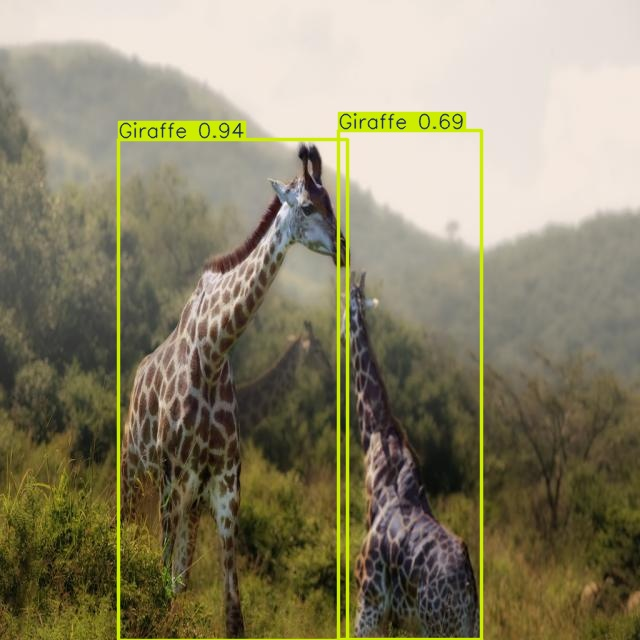

In [ ]:
# diaply detection results 
from IPython.display import Image
import glob 

pred_image = glob.glob("/kaggle/working/runs/detect/predict/*jpg")
Image(pred_image[18])

In [ ]:
# download the predictions in zip format
import shutil
import os
from IPython.display import FileLink

shutil.make_archive('my_predictions', 'zip', '/kaggle/working/runs/detect/predict')

FileLink(r'my_predictions.zip')

/kaggle/working/my_predictions.zip